In [1]:
!pip install torch-geometric
!pip install networkx
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.7 MB/s eta 0:00:00


In [2]:
import os
print(os.listdir())

['.config', 'elliptic_txs_features.csv', 'elliptic_txs_edgelist.csv', 'elliptic_txs_classes.csv', '.ipynb_checkpoints', 'sample_data']


Step 1 : DATA LOADING + UNDERSTANDING

In [3]:
import pandas as pd
import numpy as np

In [4]:
features = pd.read_csv("elliptic_txs_features.csv", header=None)
classes = pd.read_csv("elliptic_txs_classes.csv")
edges = pd.read_csv("elliptic_txs_edgelist.csv")

In [5]:
print(features.shape)
print(classes.shape)
print(edges.shape)

(4338, 167)
(203769, 2)
(234355, 2)


In [6]:
features.columns = ["txId"] + [f"feature_{i}" for i in range(1, features.shape[1])]

In [7]:
features.head()

,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [8]:
data = features.merge(classes, on="txId")

In [9]:
data.head()

,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [10]:
print(data['class'].value_counts())

class
unknown    3162
2          1171
1             5
Name: count, dtype: int64


In [11]:
data = data[data['class'] != 'unknown']

In [12]:
data['class'] = data['class'].astype(int)

In [13]:
data['class'] = data['class'].apply(lambda x: 1 if x == 1 else 0)

In [14]:
print(data['class'].value_counts())

class
0    1171
1       5
Name: count, dtype: int64


Step 2 : GRAPH CONSTRUCTION

In [15]:
!pip install torch-geometric

In [16]:
import torch
from torch_geometric.data import Data

In [17]:
X = data.drop(['txId', 'class'], axis=1).values
X = torch.tensor(X, dtype=torch.float)

In [18]:
y = data['class'].values
y = torch.tensor(y, dtype=torch.long)

In [19]:
valid_tx = set(data['txId'])

edges_filtered = edges[
    edges['txId1'].isin(valid_tx) &
    edges['txId2'].isin(valid_tx)
]

In [20]:
tx_mapping = {tx: i for i, tx in enumerate(data['txId'])}

In [21]:
edge_index = [
    [tx_mapping[src], tx_mapping[dst]]
    for src, dst in zip(edges_filtered['txId1'], edges_filtered['txId2'])
]

In [22]:
edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

In [23]:
graph_data = Data(
    x=X,
    edge_index=edge_index,
    y=y
)

In [24]:
print(graph_data)

Data(x=[1176, 166], edge_index=[2, 957], y=[1176])


In [25]:
print(graph_data.x.shape)
print(graph_data.edge_index.shape)
print(graph_data.y.shape)

torch.Size([1176, 166])
torch.Size([2, 957])
torch.Size([1176])


Step 3 : GCN (Graph Convolutional Network)

In [26]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

In [27]:
import torch.nn as nn

class GCN(nn.Module):
    def __init__(self, num_features, hidden_channels):
        super(GCN, self).__init__()

        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        return x

In [28]:
model = GCN(num_features=166, hidden_channels=32)
print(model)

GCN(
  (conv1): GCNConv(166, 32)
  (conv2): GCNConv(32, 2)
)


In [29]:
train_mask = torch.rand(graph_data.num_nodes) < 0.8

In [30]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [31]:
for epoch in range(50):
    model.train()
    optimizer.zero_grad()

    out = model(graph_data.x, graph_data.edge_index)

    loss = F.cross_entropy(out[train_mask], graph_data.y[train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 1.4333187341690063
Epoch 10, Loss: 0.018332935869693756
Epoch 20, Loss: 0.013720380142331123
Epoch 30, Loss: 0.008146862499415874
Epoch 40, Loss: 0.004642906598746777


In [32]:
for epoch in range(50):
    model.train()
    optimizer.zero_grad()

    out = model(graph_data.x, graph_data.edge_index)

    loss = F.cross_entropy(out[train_mask], graph_data.y[train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.003334238426759839
Epoch 10, Loss: 0.002643774263560772
Epoch 20, Loss: 0.0023453368339687586
Epoch 30, Loss: 0.002186801750212908
Epoch 40, Loss: 0.002101989695802331


In [33]:
model.eval()

out = model(graph_data.x, graph_data.edge_index)

pred = out.argmax(dim=1)

correct = (pred[train_mask] == graph_data.y[train_mask]).sum()

accuracy = int(correct) / int(train_mask.sum())

print("Accuracy:", accuracy)

Accuracy: 0.9978969505783386


Step 4 : GAT Model (Attention-based GNN)

In [34]:
from torch_geometric.nn import GATConv

In [35]:
import torch.nn as nn
import torch.nn.functional as F

class GAT(nn.Module):
    def __init__(self, num_features, hidden_channels):
        super(GAT, self).__init__()

        self.gat1 = GATConv(num_features, hidden_channels, heads=4)
        self.gat2 = GATConv(hidden_channels * 4, 2, heads=1)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = self.gat2(x, edge_index)

        return x

In [36]:
gat_model = GAT(num_features=166, hidden_channels=32)
print(gat_model)

GAT(
  (gat1): GATConv(166, 32, heads=4)
  (gat2): GATConv(128, 2, heads=1)
)


In [37]:
optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.01)

In [38]:
for epoch in range(50):
    gat_model.train()
    optimizer.zero_grad()

    out = gat_model(graph_data.x, graph_data.edge_index)

    loss = F.cross_entropy(out[train_mask], graph_data.y[train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"GAT Epoch {epoch}, Loss: {loss.item()}")

GAT Epoch 0, Loss: 2.451754570007324
GAT Epoch 10, Loss: 0.026127152144908905
GAT Epoch 20, Loss: 0.00706374179571867
GAT Epoch 30, Loss: 0.0033458652906119823
GAT Epoch 40, Loss: 0.002463419921696186


In [39]:
gat_model.eval()

gat_out = gat_model(graph_data.x, graph_data.edge_index)

gat_pred = gat_out.argmax(dim=1)

correct = (gat_pred[train_mask] == graph_data.y[train_mask]).sum()

accuracy = int(correct) / int(train_mask.sum())

print("GAT Accuracy:", accuracy)

GAT Accuracy: 0.9989484752891693


Step 5 : GCN vs GAT Comparison

In [44]:
model.eval()
gcn_out = model(graph_data.x, graph_data.edge_index)
gcn_pred = gcn_out.argmax(dim=1)

In [45]:
gat_model.eval()
gat_out = gat_model(graph_data.x, graph_data.edge_index)
gat_pred = gat_out.argmax(dim=1)

In [46]:
y_true = graph_data.y[train_mask]
gcn_pred = gcn_pred[train_mask]
gat_pred = gat_pred[train_mask]

In [47]:
from sklearn.metrics import accuracy_score

gcn_acc = accuracy_score(y_true, gcn_pred)
gat_acc = accuracy_score(y_true, gat_pred)

print("GCN Accuracy:", gcn_acc)
print("GAT Accuracy:", gat_acc)

GCN Accuracy: 0.9978969505783386
GAT Accuracy: 0.9989484752891693


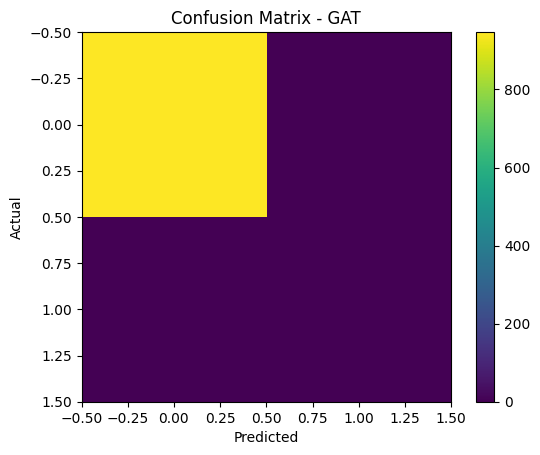

In [48]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, gat_pred)

plt.imshow(cm)
plt.title("Confusion Matrix - GAT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

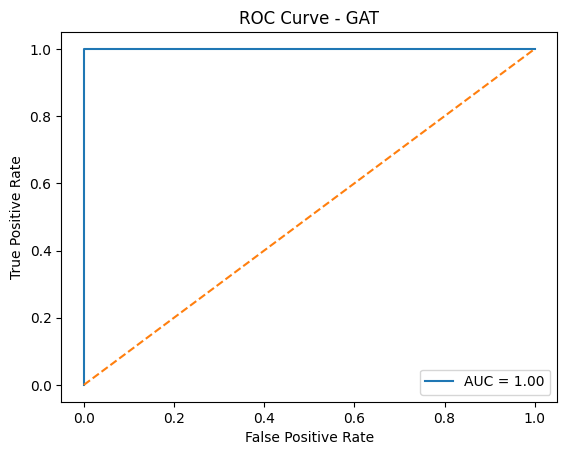

In [49]:
from sklearn.metrics import roc_curve, auc

probs = gat_out[train_mask][:,1].detach().numpy()

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GAT")
plt.legend()
plt.show()

STEP 6 : GNN EMBEDDINGS + ISOLATION FOREST
     ↪ This is our INNOVATION

In [50]:
embeddings = gat_out.detach().numpy()

In [51]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(embeddings)

IsolationForest(contamination=0.05, random_state=42)

In [52]:
anomaly_scores = iso_forest.decision_function(embeddings)

print("Shape:", anomaly_scores.shape)

Shape: (1176,)


In [53]:
anomaly_labels = iso_forest.predict(embeddings)

In [54]:
suspicious = (anomaly_labels == -1).sum()

print("Suspicious Transactions:", suspicious)

Suspicious Transactions: 59


STEP 7 : FRAUD RISK SCORING ENGINE

In [58]:
import numpy as np

# Normalize between 0 and 1
risk_scores = 1 - ((anomaly_scores - anomaly_scores.min()) / (anomaly_scores.max() - anomaly_scores.min()))

In [59]:
risk_levels = np.where(
    risk_scores > 0.65, "High Risk",
    np.where(
        risk_scores > 0.4, "Medium Risk",
        "Low Risk"
    )
)

In [60]:
unique, counts = np.unique(risk_levels, return_counts=True)

print(dict(zip(unique, counts)))

{np.str_('High Risk'): np.int64(29), np.str_('Low Risk'): np.int64(1020), np.str_('Medium Risk'): np.int64(127)}


Step 8 : Fraud Ring Detection (Community Detection)

In [61]:
import networkx as nx

In [62]:
G = nx.Graph()

# Add edges
edge_list = edge_index.t().numpy()
G.add_edges_from(edge_list)

In [63]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G)

In [64]:
print("Number of communities:", len(communities))

Number of communities: 140


In [65]:
for i, comm in enumerate(communities):
    print(f"Community {i} size:", len(comm))
    if i == 4:
        break

Community 0 size: 140
Community 1 size: 100
Community 2 size: 60
Community 3 size: 48
Community 4 size: 38


In [66]:
for i, comm in enumerate(communities):
    high_risk_count = sum([1 for node in comm if risk_levels[node] == "High Risk"])

    if high_risk_count > 5:
        print(f"🚨 Suspicious Community {i}: {high_risk_count} high-risk nodes")

🚨 Suspicious Community 0: 9 high-risk nodes


Step 9 : Suspicious Network Visualization

In [67]:
import matplotlib.pyplot as plt

In [68]:
# Pick suspicious community
suspicious_comm = list(communities)[0]

In [69]:
subgraph = G.subgraph(suspicious_comm)

In [70]:
node_colors = []

for node in subgraph.nodes():
    if risk_levels[node] == "High Risk":
        node_colors.append("red")
    elif risk_levels[node] == "Medium Risk":
        node_colors.append("orange")
    else:
        node_colors.append("green")

Color meaning
🔴 Red → Fraud
🟠 Orange → Suspicious
🟢 Green → Normal

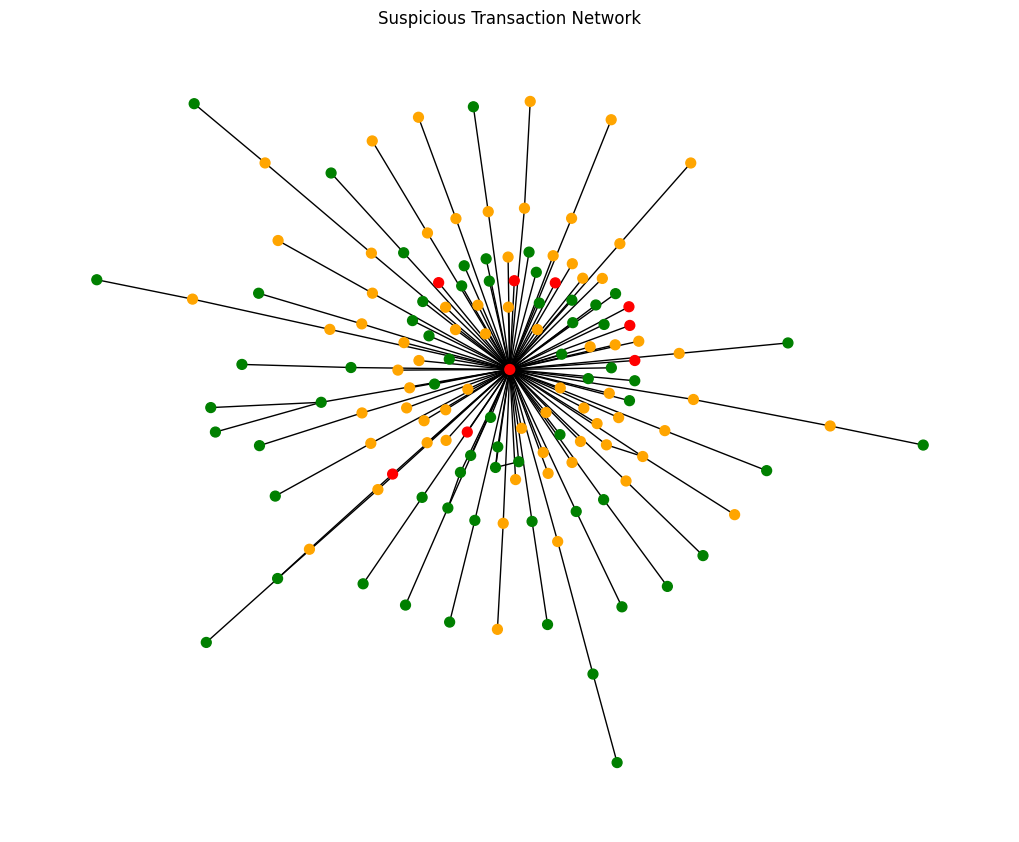

In [71]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(subgraph)

nx.draw(
    subgraph,
    pos,
    node_color=node_colors,
    with_labels=False,
    node_size=50
)

plt.title("Suspicious Transaction Network")
plt.show()

SAVE MODEL OUTPUTS

In [72]:
import pandas as pd

results = pd.DataFrame({
    "txId": data['txId'],
    "risk_score": risk_scores,
    "risk_level": risk_levels
})

results.to_csv("results.csv", index=False)